In [3]:
import coderdata as cd
import os
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Correct import for new RDKit
import pubchempy as pcp

In [73]:
import coderdata_processing
import importlib
importlib.reload(coderdata_processing)
from coderdata_processing import filter_biomarkers, filter_feature, data_attribute_check, preprocess_experiment_with_footprint, cat_drug_response_features, unify_feature_across_dataset, get_total_mutation_types, summarize_datasets, summarize_df_matrices, binarize_across_dfs,  get_cell_id_across_dfs, cat_drug_response_features_across_datasets, dip_experiments_across_dfs, slice_data_across_dfs, visualize_responses_across_datasets, summarize_all_available_metrics, clean_experiments_across_dfs, visualize_sample_response_statistics, save_dfs_as_pt

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
# datasets = ["beataml", "bladder", "ccle", "colorectal", "cptac", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "hcmi", "liver", "mpnst", "nci60", "novartis", "pancreatic", "prism", "sarcoma"]
# ignore dataset "cptac", "hcmi", "novartis", "sarcoma" due to response metric issues
datasets = ["beataml", "bladder", "ccle", "colorectal", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "liver", "mpnst", "nci60", "pancreatic", "prism"]
# avail_metrics = ["fit_auc", "fit_ic50", "fit_ec50", "fit_r2", "fit_ec50se", "fit_einf", "fit_hs", "aac", "auc", "dss"]


# bad datasets: ctrpv2, fimm, gdscv1, gdscv2, liver, mpnst, nci60, prism
# good datasets: ccle, gcsi, 
# datasets = ["prism"]
data_path = '../data/Cancer/coderdata/'
for data_name in datasets:
    cd.download(name=data_name, local_path=data_path)

loaded_datasets = {}
for data_name in datasets:
    print(f"Loading dataset: {data_name}")
    loaded_datasets[data_name] = cd.load(name=data_name, local_path=data_path)

Downloaded 'https://api.figshare.com/v2/file/download/57224264' to '../data/Cancer/coderdata/genes.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224267' to '../data/Cancer/coderdata/beataml_drugs.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224348' to '../data/Cancer/coderdata/beataml_experiments.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224435' to '../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224456' to '../data/Cancer/coderdata/beataml_transcriptomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224459' to '../data/Cancer/coderdata/beataml_proteomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224462' to '../data/Cancer/coderdata/beataml_mutations.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57349832' to '../data/Cancer/coderdata/beataml_samples.csv'
Downloaded 'https://api.figshare.com/v2/file/download

Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/beataml_transcriptomics.csv.gz ... DONE
Importing 'proteomics' from ../data/Cancer/coderdata/beataml_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/beataml_mutations.csv.gz ... DONE
'copy_number' not available for beataml
Importing 'samples' from ../data/Cancer/coderdata/beataml_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/beataml_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz ... DONE
'mirna' not available for beataml
Importing 'experiments' from ../data/Cancer/coderdata/beataml_experiments.tsv.gz ... DONE
'methylation' not available for beataml
'metabolomics' not available for beataml
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/bladder_transcriptomics.

Loading dataset: bladder


DONE
'proteomics' not available for bladder
Importing 'mutations' from ../data/Cancer/coderdata/bladder_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/bladder_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/bladder_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/bladder_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/bladder_drug_descriptors.tsv.gz ... DONE
'mirna' not available for bladder
Importing 'experiments' from ../data/Cancer/coderdata/bladder_experiments.tsv.gz ... DONE
'methylation' not available for bladder
'metabolomics' not available for bladder
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/ccle_transcriptomics.csv.gz ... 

Loading dataset: ccle


...

DONE
Importing 'proteomics' from ../data/Cancer/coderdata/nci60_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/nci60_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/nci60_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/nci60_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/nci60_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/nci60_drug_descriptors.tsv.gz ... DONE
'mirna' not available for nci60
Importing 'experiments' from ../data/Cancer/coderdata/nci60_experiments.tsv.gz ... DONE
'methylation' not available for nci60
'metabolomics' not available for nci60
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/pancreatic_transcriptomics.csv.gz ... 

Loading dataset: pancreatic


DONE
'proteomics' not available for pancreatic
Importing 'mutations' from ../data/Cancer/coderdata/pancreatic_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/pancreatic_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/pancreatic_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/pancreatic_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/pancreatic_drug_descriptors.tsv.gz ... DONE
'mirna' not available for pancreatic
Importing 'experiments' from ../data/Cancer/coderdata/pancreatic_experiments.tsv.gz ... DONE
'methylation' not available for pancreatic
'metabolomics' not available for pancreatic
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/prism_transcriptomics.csv.gz ... 

Loading dataset: prism


DONE
Importing 'proteomics' from ../data/Cancer/coderdata/prism_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/prism_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/prism_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/prism_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/prism_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/prism_drug_descriptors.tsv.gz ... DONE
'mirna' not available for prism
Importing 'experiments' from ../data/Cancer/coderdata/prism_experiments.tsv.gz ... DONE
'methylation' not available for prism
'metabolomics' not available for prism
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE


In [ ]:
avail_metrics = summarize_all_available_metrics(loaded_datasets)
avail_metrics

Available metrics in dataset 'beataml': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'bladder': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ccle': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'colorectal': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ctrpv2': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'fimm': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gcsi': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gdscv1': ['fit_auc' 'fit_ic50' '

['fit_auc',
 'fit_ec50se',
 'fit_hs',
 'auc',
 'fit_einf',
 'aac',
 'fit_ic50',
 'fit_r2',
 'fit_ec50',
 'dss']

In [8]:
for metric in avail_metrics:
    visualize_responses_across_datasets(loaded_datasets, metric=metric)

Dataset: beataml
📊 Summary statistics for `fit_auc`:

count    31926.000000
mean         0.725942
std          0.141179
min          0.000000
5%           0.475125
25%          0.648000
50%          0.746700
75%          0.822700
95%          0.919600
max          1.000000

Distribution plot saved to ../plts/response_metrics/beataml/fit_auc_distribution.png
Dataset: bladder
📊 Summary statistics for `fit_auc`:

count    3300.000000
mean        0.723401
std         0.169994
min         0.189900
5%          0.411900
25%         0.614400
50%         0.751800
75%         0.858100
95%         0.961300
max         0.999600

Distribution plot saved to ../plts/response_metrics/bladder/fit_auc_distribution.png
Dataset: ccle
📊 Summary statistics for `fit_auc`:

count    11543.000000
mean         0.781072
std          0.166781
min          0.027500
5%           0.447310
25%          0.719700
50%          0.822800
75%          0.896050
95%          0.972700
max          1.000000

Distribution plot 

In [9]:
data_attribute_check(loaded_datasets)

Dataset 'beataml' is missing: copy_number
Dataset 'bladder' is missing: proteomics
Dataset 'ccle' has all required features ✅
Dataset 'colorectal' is missing: proteomics
Dataset 'ctrpv2' has all required features ✅
Dataset 'fimm' has all required features ✅
Dataset 'gcsi' has all required features ✅
Dataset 'gdscv1' has all required features ✅
Dataset 'gdscv2' has all required features ✅
Dataset 'liver' has all required features ✅
Dataset 'mpnst' has all required features ✅
Dataset 'nci60' has all required features ✅
Dataset 'pancreatic' is missing: proteomics
Dataset 'prism' has all required features ✅


In [10]:
summary = summarize_datasets(loaded_datasets)

In [11]:
for key, value in summary.items():
    print(f"{key}: ")
    for sub_key, sub_value in value.items():
        if sub_key == "transcriptomics":
            print(f"  {sub_key}: ")
            print(sub_value)

beataml: 
  transcriptomics: 
                     dtype  num_null  pct_null  num_inf  num_unique     min  \
column                                                                        
improve_sample_id    int64         0       0.0        0         707  2074.0   
transcriptomics    float64         0       0.0        0    10620832     0.0   
entrez_id            int64         0       0.0        0       19139     1.0   
source              object         0       0.0        0           1     NaN   
study               object         0       0.0        0           1     NaN   

                            max  \
column                            
improve_sample_id  3.074000e+03   
transcriptomics    1.482622e+05   
entrez_id          1.316758e+08   
source                      NaN   
study                       NaN   

                                                      example_values  
column                                                                
improve_sample_id           

In [12]:
include_copy_number = True
include_proteomics = True

to_remove = ["cptac", "hcmi"]
if (include_copy_number):
    new_to_remove = ["beataml", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

if (include_proteomics):
    new_to_remove = ["bladder", "colorectal", "novartis", "pancreatic", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

selected_datasets = {x: loaded_datasets[x] for x in datasets if x not in to_remove}

In [13]:
# unify entries for each feature across datasets 
unified_datasets = {}
unified_datasets["transcriptomics"] = unify_feature_across_dataset(selected_datasets, feature="transcriptomics")
if include_proteomics:
    unified_datasets["proteomics"] = unify_feature_across_dataset(selected_datasets, feature="proteomics")
if include_copy_number:
    unified_datasets["copy_number"] = unify_feature_across_dataset(selected_datasets, feature="copy_number")
# for mutations, need to get total mutation variation types
all_mutation_types = get_total_mutation_types(selected_datasets)
for mut_type in all_mutation_types:
    unified_datasets[f"mutations_{mut_type}"] = unify_feature_across_dataset(selected_datasets, feature="mutations", mutation_type=mut_type)
unique_cell_ids_across_dfs = get_cell_id_across_dfs(unified_datasets)
print(f"Unified features {unified_datasets.keys()} across datasets.")

Unified features dict_keys(['transcriptomics', 'proteomics', 'copy_number', "mutations_5'Flank", 'mutations_Translation_Start_Site', "mutations_3'UTR", "mutations_3'Flank", 'mutations_In_Frame_Ins', "mutations_5'UTR", 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Intron', 'mutations_Silent', 'mutations_Frame_Shift_Ins', 'mutations_Stop_Codon_Del', 'mutations_Splice_Region', 'mutations_Nonstop_Mutation', 'mutations_Splice_Site', 'mutations_Frame_Shift_Del', 'mutations_Start_Codon_Ins', 'mutations_Missense_Mutation', 'mutations_Start_Codon_Del', 'mutations_Start_Codon_SNP']) across datasets.


In [14]:
summary2 = summarize_df_matrices(unified_datasets)

In [15]:
print(summary2.keys())

dict_keys(['transcriptomics', 'proteomics', 'copy_number', "mutations_5'Flank", 'mutations_Translation_Start_Site', "mutations_3'UTR", "mutations_3'Flank", 'mutations_In_Frame_Ins', "mutations_5'UTR", 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Intron', 'mutations_Silent', 'mutations_Frame_Shift_Ins', 'mutations_Stop_Codon_Del', 'mutations_Splice_Region', 'mutations_Nonstop_Mutation', 'mutations_Splice_Site', 'mutations_Frame_Shift_Del', 'mutations_Start_Codon_Ins', 'mutations_Missense_Mutation', 'mutations_Start_Codon_Del', 'mutations_Start_Codon_SNP'])


In [16]:
data_size_ref = {}
for data, value in unified_datasets["transcriptomics"].items():
    data_size_ref[data] = value.shape[0]
print(data_size_ref)

{'ccle': 474, 'ctrpv2': 822, 'fimm': 48, 'gcsi': 528, 'gdscv1': 973, 'gdscv2': 799, 'liver': 62, 'mpnst': 33, 'nci60': 69, 'prism': 473}


In [17]:
# Filter out biomarkers with too few samples
feature_reduced_dfs = filter_biomarkers(unified_datasets, data_size_ref, proportion=1e-2)

Feature mutations_5'Flank is filtered out due to insufficient samples
Feature mutations_Translation_Start_Site is filtered out due to insufficient samples
Feature mutations_3'UTR is filtered out due to insufficient samples
Feature mutations_3'Flank is filtered out due to insufficient samples
Feature mutations_5'UTR is filtered out due to insufficient samples
Feature mutations_Intron is filtered out due to insufficient samples
Feature mutations_Stop_Codon_Del is filtered out due to insufficient samples
Feature mutations_Splice_Region is filtered out due to insufficient samples
Feature mutations_Start_Codon_Del is filtered out due to insufficient samples


In [18]:
dim_reduced_dfs = filter_feature(feature_reduced_dfs)
# Normalization
dim_reduced_dfs["transcriptomics"] = binarize_across_dfs(dim_reduced_dfs["transcriptomics"], "transcriptomics")
if include_proteomics:
    dim_reduced_dfs["proteomics"] = binarize_across_dfs(dim_reduced_dfs["proteomics"], "proteomics")
if include_copy_number:
    dim_reduced_dfs["copy_number"] = binarize_across_dfs(dim_reduced_dfs["copy_number"], "copy_number")

Feature transcriptomics: selected 19048 out of 19425 features
Feature proteomics: selected 12959 out of 12960 features
Feature copy_number: selected 27287 out of 27287 features
Feature mutations_In_Frame_Ins: selected 237 out of 697 features
Feature mutations_Nonsense_Mutation: selected 3521 out of 13426 features
Feature mutations_In_Frame_Del: selected 681 out of 5092 features
Feature mutations_Silent: selected 13682 out of 18026 features
Feature mutations_Frame_Shift_Ins: selected 1106 out of 6007 features
Feature mutations_Nonstop_Mutation: selected 122 out of 630 features
Feature mutations_Splice_Site: selected 5262 out of 15247 features
Feature mutations_Frame_Shift_Del: selected 3584 out of 13686 features
Feature mutations_Start_Codon_Ins: selected 12 out of 12 features
Feature mutations_Missense_Mutation: selected 17830 out of 18915 features
Feature mutations_Start_Codon_SNP: selected 116 out of 899 features


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFra

/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits = scaled_df.applymap(lambda x: [int(b) for b in format(x, f'0{nbit}b')])
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:438: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bits_array = df_bits.applymap(np.array)
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:437: FutureWarning: DataFrame.applymap has been deprecated. Use DataFra

In [19]:
drugs_ref_dfs = {}
for name, data in selected_datasets.items():
    drugs_ref_dfs[name] = data.drugs.drop_duplicates(subset=["improve_drug_id"], inplace=False)

metric = "fit_auc"
experiments_dfs = clean_experiments_across_dfs(selected_datasets, metric=metric)

/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


Dataset 'ccle': Cleaned 2780 rows with NaN or infinite 'dose_response_value' values.
Dataset 'ctrpv2': Cleaned 156304 rows with NaN or infinite 'dose_response_value' values.
Dataset 'fimm': Cleaned 693 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gcsi': Cleaned 3495 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

Dataset 'gdscv1': Cleaned 93396 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gdscv2': Cleaned 45480 rows with NaN or infinite 'dose_response_value' values.
Dataset 'liver': Cleaned 669 rows with NaN or infinite 'dose_response_value' values.
Dataset 'mpnst': Cleaned 54 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

Dataset 'nci60': Cleaned 1831668 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


Dataset 'prism': Cleaned 129445 rows with NaN or infinite 'dose_response_value' values.


In [20]:
experiments_dfs_sampled = dip_experiments_across_dfs(experiments_dfs, fraction=0.01)

In [55]:
experiments_dfs_sampled

{'ccle':            source  improve_sample_id improve_drug_id study  time time_unit  \
 1576   pharmacoGX                266       SMI_36112  CCLE    72     hours   
 10420  pharmacoGX               1778       SMI_23457  CCLE    72     hours   
 2028   pharmacoGX                347       SMI_31997  CCLE    72     hours   
 4790   pharmacoGX                690       SMI_44331  CCLE    72     hours   
 9960   pharmacoGX               1652       SMI_36067  CCLE    72     hours   
 ...           ...                ...             ...   ...   ...       ...   
 1289   pharmacoGX                177       SMI_48746  CCLE    72     hours   
 6174   pharmacoGX                849       SMI_41675  CCLE    72     hours   
 9390   pharmacoGX               1461       SMI_37951  CCLE    72     hours   
 466    pharmacoGX                 63       SMI_57322  CCLE    72     hours   
 1235   pharmacoGX                172       SMI_36112  CCLE    72     hours   
 
       dose_response_metric  dose_response

📊 Summary statistics:

count    20499.000000
mean         0.762644
std          0.126471
min          0.000000
5%           0.503990
25%          0.715400
50%          0.796200
75%          0.852600
95%          0.891500
max          0.900000



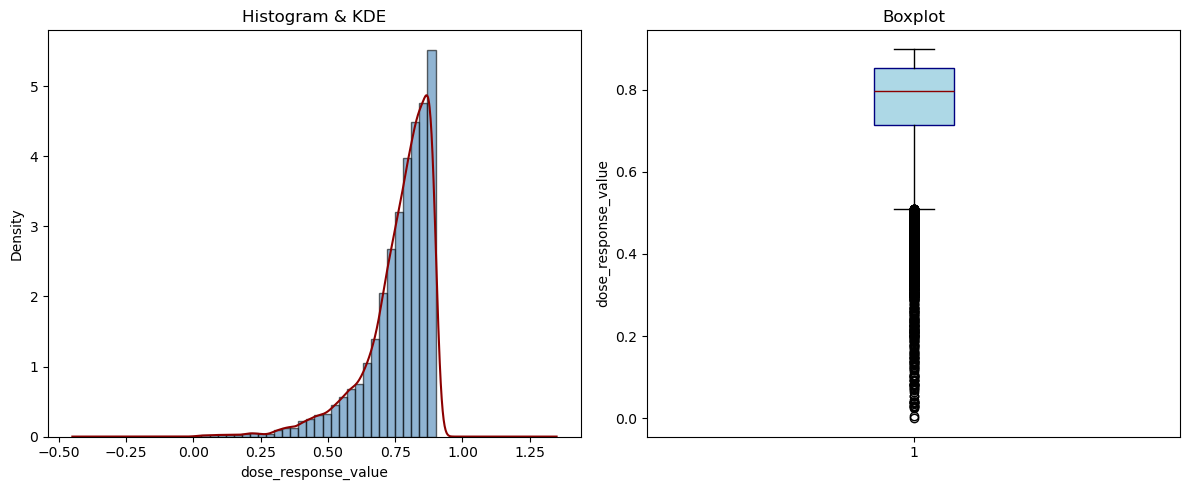

In [21]:
visualize_sample_response_statistics(experiments_dfs_sampled)

In [22]:
feature_dict_footprint, resp_footprint = preprocess_experiment_with_footprint(experiments_dfs_sampled, drugs_ref_dfs, dim_reduced_dfs, drug_target=None, show_status=True)

Processing dataset: ccle with 88 experiments
Finished processing dataset: ccle with 88 selected samples
Processing dataset: ctrpv2 with 1531 experiments
Finished processing dataset: ctrpv2 with 1531 selected samples
Processing dataset: fimm with 20 experiments
Finished processing dataset: fimm with 20 selected samples
Processing dataset: gcsi with 99 experiments
Finished processing dataset: gcsi with 99 selected samples
Processing dataset: gdscv1 with 1544 experiments
Finished processing dataset: gdscv1 with 1544 selected samples
Processing dataset: gdscv2 with 700 experiments
Finished processing dataset: gdscv2 with 700 selected samples
Processing dataset: liver with 38 experiments
Finished processing dataset: liver with 38 selected samples
Processing dataset: mpnst with 2 experiments
Finished processing dataset: mpnst with 2 selected samples
Processing dataset: nci60 with 11382 experiments


[07:51:44] Explicit valence for atom # 0 Cl, 1, is greater than permitted


Invalid SMILES for drug ID SMI_55935
Skipping experiment 154065 with drug ID SMI_55935 due to invalid SMILES
Finished processing dataset: nci60 with 11381 selected samples
Processing dataset: prism with 5095 experiments
Finished processing dataset: prism with 5095 selected samples


In [39]:
# X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])
X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])

In [40]:
print(X.shape)

is_binary = np.all((X == 0) | (X == 1))

print(is_binary)  # True if all 0 or 1, False otherwise

(11512, 303238)
True


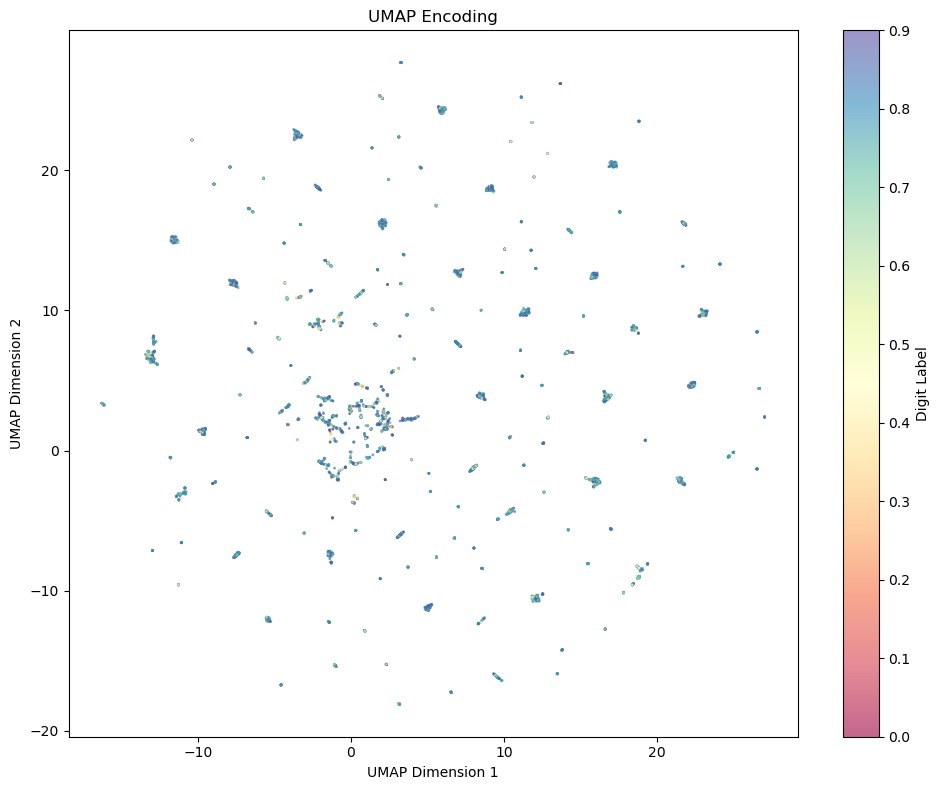

In [41]:
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

In [76]:
save_dfs_as_pt(
    experiments_dfs_sampled,
    drugs_ref_dfs,
    dim_reduced_dfs,
    unique_cell_ids_across_dfs,
    features=["transcriptomics", "copy_number"],
    n_chunks=2,
    save_dir=f"../data/pt_data/"
)

Processing chunk 1/2...
Processing dataset: ccle with 44 experiments
Finished processing dataset: ccle with 44 selected samples
Processing dataset: ctrpv2 with 765 experiments
Finished processing dataset: ctrpv2 with 765 selected samples
Processing dataset: fimm with 10 experiments
Finished processing dataset: fimm with 10 selected samples
Processing dataset: gcsi with 49 experiments
Finished processing dataset: gcsi with 49 selected samples
Processing dataset: gdscv1 with 772 experiments
Finished processing dataset: gdscv1 with 772 selected samples
Processing dataset: gdscv2 with 350 experiments
Finished processing dataset: gdscv2 with 350 selected samples
Processing dataset: liver with 19 experiments
Finished processing dataset: liver with 19 selected samples
Processing dataset: mpnst with 1 experiments
Finished processing dataset: mpnst with 1 selected samples
Processing dataset: nci60 with 5691 experiments


[10:30:15] Explicit valence for atom # 0 Cl, 1, is greater than permitted


Invalid SMILES for drug ID SMI_55935
Skipping experiment 154065 with drug ID SMI_55935 due to invalid SMILES
Finished processing dataset: nci60 with 5690 selected samples
Processing dataset: prism with 2547 experiments
Finished processing dataset: prism with 2547 selected samples
Dataset 'ccle': (40, 225484)
selected Dataset 'ccle': (40, 225484)
Dataset 'ctrpv2': (734, 225484)
selected Dataset 'ctrpv2': (734, 225484)
Dataset 'fimm': (9, 225484)
selected Dataset 'fimm': (9, 225484)
Dataset 'gcsi': (48, 225484)
selected Dataset 'gcsi': (48, 225484)
Dataset 'gdscv1': (753, 225484)
selected Dataset 'gdscv1': (753, 225484)
Dataset 'gdscv2': (342, 225484)
selected Dataset 'gdscv2': (342, 225484)
Dataset 'liver': (19, 225484)
selected Dataset 'liver': (19, 225484)
Dataset 'mpnst': (1, 225484)
selected Dataset 'mpnst': (1, 225484)
Dataset 'nci60': (4464, 225484)
selected Dataset 'nci60': (4464, 225484)
Dataset 'prism': (2515, 225484)
selected Dataset 'prism': (2515, 225484)
Processing chunk 2/